In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

In [2]:
df_AQ = pd.read_csv("DelhiPollutionData_full_MandirMarg.csv")

In [3]:
df_modi = pd.read_csv("modis_new.csv")

In [4]:
df_wind = pd.read_csv("WindDataNew.csv")
df_wind['valid_time'] = pd.to_datetime(df_wind['valid_time']).dt.tz_localize('UTC').dt.tz_convert('UTC')


In [5]:
delhi_wind = df_wind[
    (df_wind["latitude"] == 28.75) &
    (df_wind["longitude"] == 77.25)
].copy()

delhi_wind["wind_speed"] = np.sqrt(
    delhi_wind["u10"]**2 +
    delhi_wind["v10"]**2
)

delhi_wind["temperature_C"] = (
    delhi_wind["t2m"] - 273.15
)

In [6]:
weather = delhi_wind[
    [
        "valid_time",
        "wind_speed",
        "temperature_C"
    ]
].copy()

weather = weather.rename(
    columns={"valid_time": "datetime"}
)

In [7]:
aq = df_AQ.copy()

aq["datetime"] = pd.to_datetime(aq["datetime"], utc=True)

aq = aq.sort_values("datetime")

pm25 = (
    aq[aq["parameter"] == "pm25"]
    .set_index("datetime")["value"]
    .resample("1h")
    .mean()
    .rename("pm25")
)

pm10 = (
    aq[aq["parameter"] == "pm10"]
    .set_index("datetime")["value"]
    .resample("1h")
    .mean()
    .rename("pm10")
)

aq_hourly = pd.concat(
    [pm25, pm10],
    axis=1
).reset_index()


In [8]:
wind = df_wind.copy()

wind["time"] = pd.to_datetime(
    wind["time"],
    utc=True
)

In [9]:
station_lat = 28.636429
station_lon = 77.201067

grid_points = df_wind[["latitude", "longitude"]].drop_duplicates().copy()

grid_points["distance"] = (
    (grid_points["latitude"] - station_lat)**2 +
    (grid_points["longitude"] - station_lon)**2
)

print(grid_points.sort_values("distance").head(5))

   latitude  longitude  distance
5     28.75      77.25  0.015293
8     28.50      77.25  0.021007
4     28.75      77.00  0.053326
7     28.50      77.00  0.059041
2     29.00      77.25  0.134578


In [10]:
aq_hourly = aq_hourly.set_index("datetime")

# Only fill SHORT gaps (≤3 consecutive missing hours) — long gaps (like the 1113-hour one) stay NaN
aq_hourly["pm25_filled"] = aq_hourly["pm25"].interpolate(method="time", limit=3, limit_area="inside")
aq_hourly["pm10_filled"] = aq_hourly["pm10"].interpolate(method="time", limit=3, limit_area="inside")

aq_hourly = aq_hourly.reset_index()
print(aq_hourly[["pm25", "pm25_filled"]].isna().sum())

pm25           8982
pm25_filled    6474
dtype: int64


In [11]:
merged = pd.merge(aq_hourly, weather, on="datetime", how="left")
print(merged.shape)
print(merged.isna().sum())

(15353, 7)
datetime            0
pm25             8982
pm10             9023
pm25_filled      6474
pm10_filled      6507
wind_speed          0
temperature_C       0
dtype: int64


In [12]:

df_modi["acq_time_str"] = df_modi["acq_time"].astype(str).str.zfill(4)
df_modi["acq_datetime"] = pd.to_datetime(
    df_modi["acq_date"].astype(str) + df_modi["acq_time_str"],
    format="%Y-%m-%d%H%M",
    utc=True
)

fires = df_modi[df_modi["confidence"] >= 50].copy()
if "type" in fires.columns:
    fires = fires[fires["type"] == 0]


fires = fires[
    (fires["latitude"].between(27.5, 32.5)) &
    (fires["longitude"].between(73.5, 77.5))
]


fires["acq_date_only"] = fires["acq_datetime"].dt.date
daily_fires = fires.groupby("acq_date_only").agg(
    fire_count=("latitude", "count"),
    total_frp=("frp", "sum")
).reset_index()

daily_fires["acq_date_only"] = pd.to_datetime(daily_fires["acq_date_only"], utc=True)
print(daily_fires.shape)
print(daily_fires.head())

(555, 3)
              acq_date_only  fire_count  total_frp
0 2020-09-09 00:00:00+00:00           4       37.7
1 2020-09-10 00:00:00+00:00           2       12.0
2 2020-09-12 00:00:00+00:00           4       33.5
3 2020-09-14 00:00:00+00:00           1       16.5
4 2020-09-16 00:00:00+00:00           1       13.9


(555, 3)
                acq_date_only  fire_count  total_frp
349 2021-11-09 00:00:00+00:00        1813    32816.7
347 2021-11-07 00:00:00+00:00        1748    34776.1
55  2020-11-06 00:00:00+00:00        1457    25874.5
53  2020-11-04 00:00:00+00:00        1344    27271.8
340 2021-10-31 00:00:00+00:00        1342    19161.2
342 2021-11-02 00:00:00+00:00        1197    22807.9
48  2020-10-30 00:00:00+00:00        1194    20746.6
46  2020-10-28 00:00:00+00:00        1055    15774.4
62  2020-11-13 00:00:00+00:00         963    13077.1
351 2021-11-11 00:00:00+00:00         957    18851.9


<Axes: xlabel='acq_date_only'>

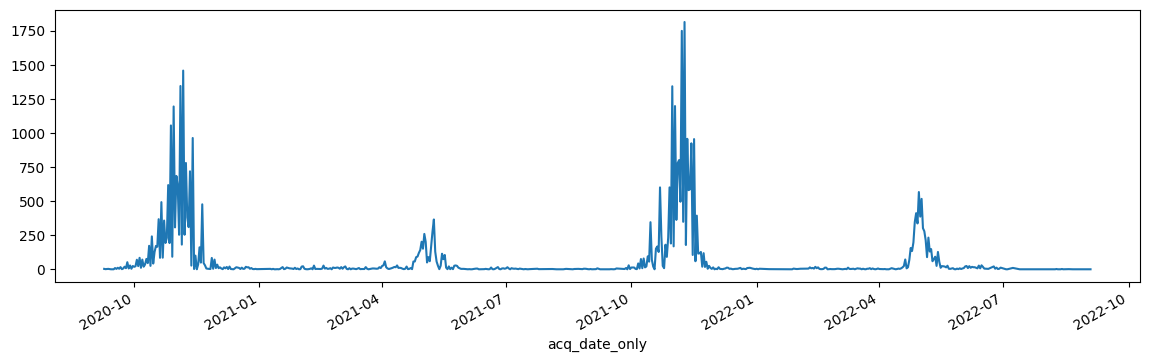

In [13]:
print(daily_fires.shape)
print(daily_fires.sort_values("fire_count", ascending=False).head(10))

daily_fires.set_index("acq_date_only")["fire_count"].plot(figsize=(14,4))

In [14]:
daily_fires = daily_fires.set_index("acq_date_only").sort_index()
daily_fires = daily_fires.asfreq("D", fill_value=0)

daily_fires["fires_last_24h"] = daily_fires["fire_count"].shift(1).rolling(1).sum()
daily_fires["fires_last_48h"] = daily_fires["fire_count"].shift(1).rolling(2).sum()
daily_fires["fires_last_72h"] = daily_fires["fire_count"].shift(1).rolling(3).sum()

daily_fires["frp_last_24h"] = daily_fires["total_frp"].shift(1).rolling(1).sum()
daily_fires["frp_last_48h"] = daily_fires["total_frp"].shift(1).rolling(2).sum()
daily_fires["frp_last_72h"] = daily_fires["total_frp"].shift(1).rolling(3).sum()

daily_fires = daily_fires.reset_index().rename(columns={"acq_date_only": "date"})

In [15]:
merged["date"] = merged["datetime"].dt.date
daily_fires["date"] = pd.to_datetime(daily_fires["date"]).dt.date

fire_cols = ["date", "fires_last_24h", "fires_last_48h", "fires_last_72h",
             "frp_last_24h", "frp_last_48h", "frp_last_72h"]

merged = pd.merge(merged, daily_fires[fire_cols], on="date", how="left")

print(merged.shape)
print(merged[fire_cols[1:]].isna().sum())

(15353, 14)
fires_last_24h    118
fires_last_48h    142
fires_last_72h    166
frp_last_24h      118
frp_last_48h      142
frp_last_72h      166
dtype: int64


In [16]:
'''Claude's Plan'''

for lag in [1, 2, 3, 6, 12, 24]:
    merged[f"pm25_lag{lag}"] = merged["pm25"].shift(lag)
    merged[f"pm10_lag{lag}"] = merged["pm10"].shift(lag)


merged["pm25_target_t+1"] = merged["pm25"].shift(-1)


model_df = merged.dropna(subset=["pm25_target_t+1"]).copy()
print(model_df.shape)

(6370, 27)


In [17]:
split_point = int(len(model_df) * 0.8)
train = model_df.iloc[:split_point]
test = model_df.iloc[split_point:]

print("Train range:", train["datetime"].min(), "→", train["datetime"].max())
print("Test range:", test["datetime"].min(), "→", test["datetime"].max())

Train range: 2020-09-05 06:00:00+00:00 → 2022-03-29 00:00:00+00:00
Test range: 2022-03-29 01:00:00+00:00 → 2022-06-06 17:00:00+00:00


# ML Model Training and Testing

In [18]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error

# ============================================================
# 1. TIME FEATURES (adds onto your existing `merged` dataframe)
# ============================================================
def time_features(df):
    df = df.copy()
    df["hour_of_day"] = df["datetime"].dt.hour
    df["day_of_week"] = df["datetime"].dt.dayofweek
    df["month"] = df["datetime"].dt.month
    df["is_rush_hour"] = df["hour_of_day"].isin([8, 9, 19, 20, 21]).astype(int)
    return df


FEATURES = [
    "hour_of_day", "day_of_week", "month", "is_rush_hour",
    "pm25_lag1", "pm25_lag2", "pm25_lag3", "pm25_lag6", "pm25_lag12", "pm25_lag24",
    "pm10_lag1", "pm10_lag2", "pm10_lag3", "pm10_lag6", "pm10_lag12", "pm10_lag24",
    "wind_speed", "temperature_C",
    "fires_last_24h", "fires_last_48h", "fires_last_72h",
    "frp_last_24h", "frp_last_48h", "frp_last_72h",
]


def time_based_split(df, test_days=21):
    cutoff = df["datetime"].max() - pd.Timedelta(days=test_days)
    train = df[df["datetime"] <= cutoff].copy()
    test = df[df["datetime"] > cutoff].copy()
    return train, test


# ============================================================
# 2. CONCENTRATION -> AQI  (CPCB breakpoint formula)
# ============================================================
# FIX: brackets are now contiguous (no 1-unit gaps between them), so every
# possible float concentration lands in exactly one bracket. The old table
# had gaps like 90-91 and 250-251 that silently fell through to a "500"
# fallback for ANY concentration landing in that gap - that produced the
# random AQI=500 spikes in the forecast.
BREAKPOINTS = {
    "pm25": [(0, 30, 0, 50), (30, 60, 50, 100), (60, 90, 100, 200),
             (90, 120, 200, 300), (120, 250, 300, 400), (250, 500, 400, 500)],
    "pm10": [(0, 50, 0, 50), (50, 100, 50, 100), (100, 250, 100, 200),
             (250, 350, 200, 300), (350, 430, 300, 400), (430, 700, 400, 500)],
}


def concentration_to_subindex(conc, pollutant):
    bps = BREAKPOINTS[pollutant]
    conc = max(conc, 0)
    for bp_lo, bp_hi, i_lo, i_hi in bps:
        if bp_lo <= conc <= bp_hi:
            return i_lo + (i_hi - i_lo) / (bp_hi - bp_lo) * (conc - bp_lo)
    # only reached if conc is above the top bracket - clip to the max index
    return bps[-1][3]


def compute_aqi(row):
    subs = {p: concentration_to_subindex(row[p], p) for p in ["pm25", "pm10"]}
    dominant = max(subs, key=subs.get)
    return subs[dominant], dominant


# ============================================================
# 3. MODEL TRAINING (one model per pollutant, all 72 horizons at once)
# ============================================================
def build_direct_training_set(df, target, horizons=range(1, 73)):
    frames = []
    for h in horizons:
        f = df.copy()
        f["horizon"] = h
        f["target"] = df[target].shift(-h)
        frames.append(f)
    stacked = pd.concat(frames, ignore_index=True)
    return stacked.dropna(subset=["target"] + FEATURES)


def train_direct_model(train_df, target):
    data = build_direct_training_set(train_df, target)
    X = data[FEATURES + ["horizon"]]
    y = data["target"]
    model = lgb.LGBMRegressor(
        n_estimators=150, learning_rate=0.05, max_depth=5,
        min_child_samples=30, random_state=42
    )
    model.fit(X, y)
    return model


# ============================================================
# 4. EVALUATION
# ============================================================
def evaluate_by_horizon(model, test_df, target, horizons=(1, 6, 24, 48, 72)):
    results = {}
    for h in horizons:
        df = test_df.copy()
        df["target"] = df[target].shift(-h)
        df["horizon"] = h
        df = df.dropna(subset=["target"] + FEATURES)
        X = df[FEATURES + ["horizon"]]
        preds = model.predict(X)
        mae = mean_absolute_error(df["target"], preds)
        persistence_mae = mean_absolute_error(df["target"], df[f"{target}_lag1"])
        results[h] = {"model_mae": round(mae, 1), "persistence_mae": round(persistence_mae, 1)}
    return pd.DataFrame(results).T


# ============================================================
# 5. FORECAST FOR A SPECIFIC FUTURE DATETIME
# ============================================================
def get_latest_conditions(df):
    return df.sort_values("datetime").dropna(subset=FEATURES).iloc[-1]


def _time_features_for(target_datetime, latest_row):
    """Time-of-day features for the timestamp being FORECAST, not the anchor row."""
    row = latest_row[FEATURES].to_dict()
    row["hour_of_day"] = target_datetime.hour
    row["day_of_week"] = target_datetime.dayofweek
    row["month"] = target_datetime.month
    row["is_rush_hour"] = int(target_datetime.hour in [8, 9, 19, 20, 21])
    return row


def predict_at_time(models, df, target_datetime):
    target_datetime = pd.Timestamp(target_datetime)
    latest_row = get_latest_conditions(df)
    latest_time = latest_row["datetime"]
    horizon_hours = int((target_datetime - latest_time).total_seconds() / 3600)

    if horizon_hours < 1:
        raise ValueError(f"'{target_datetime}' isn't after the latest data ({latest_time}).")
    if horizon_hours > 72:
        print(f"Note: {horizon_hours}h ahead is past the 72h trained window - rough guess only.")

    # FIX: hour_of_day/day_of_week/month/is_rush_hour now describe the TARGET
    # time being forecast, not the anchor row's time.
    row = _time_features_for(target_datetime, latest_row)
    row["horizon"] = horizon_hours
    X = pd.DataFrame([row])[FEATURES + ["horizon"]]

    predictions = {p: max(float(model.predict(X)[0]), 0) for p, model in models.items()}
    aqi, dominant = compute_aqi(predictions)

    print(f"Forecast for {target_datetime} ({horizon_hours}h ahead of {latest_time}):")
    for pollutant, value in predictions.items():
        print(f"  {pollutant}: {value:.1f} ug/m3")
    print(f"  AQI: {aqi:.0f} (dominant: {dominant})")
    return predictions, aqi, dominant


# ============================================================
# MAIN - uses your existing `merged` dataframe directly
# ============================================================
df = time_features(merged)

train, test = time_based_split(df, test_days=21)

# FIX: train/test are passed straight into the model functions below instead
# of a pre-filtered train.dropna(subset=FEATURES) / test.dropna(subset=FEATURES).
# train/test are still one continuous row per hour (resample("1h") guarantees
# that). build_direct_training_set() and evaluate_by_horizon() already run
# .dropna(subset=["target"] + FEATURES) themselves - but only AFTER shift(-h).
# Dropping NaNs first made shift(-h) shift by h *rows*, which only equals h
# *hours* when there are zero gaps. Since most rows were being dropped for
# missing features, "24 rows ahead" was landing anywhere from 24 hours to
# several days ahead depending on where the gaps fell.
print(f"train rows (continuous): {len(train)}, test rows (continuous): {len(test)}")

print("\nTraining PM2.5 model...")
model_pm25 = train_direct_model(train, target="pm25")

print("\nTraining PM10 model...")
model_pm10 = train_direct_model(train, target="pm10")

models = {"pm25": model_pm25, "pm10": model_pm10}

print("\nPM2.5 - model vs naive persistence, by horizon:")
print(evaluate_by_horizon(model_pm25, test, target="pm25"))

print("\nPM10 - model vs naive persistence, by horizon:")
print(evaluate_by_horizon(model_pm10, test, target="pm10"))

latest_known = get_latest_conditions(test)["datetime"]
demo_target = latest_known + pd.Timedelta(hours=24)  # "tomorrow" relative to the data, not the calendar

predictions, aqi, dominant = predict_at_time(models, test, target_datetime=demo_target)

print(f"\n(For the demo: presenting this as a 24-hour-ahead forecast from the system's")
print(f"most recent live reading, rather than an absolute date - since our current")
print(f"data source only provides history through {latest_known.date()}.)")


train rows (continuous): 14849, test rows (continuous): 504

Training PM2.5 model...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001506 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4541
[LightGBM] [Info] Number of data points in the train set: 131174, number of used features: 25
[LightGBM] [Info] Start training from score 143.569431
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

In [19]:
results_pm25 = evaluate_by_horizon(model_pm25, test, target="pm25")
print(results_pm25)

results_pm10 = evaluate_by_horizon(model_pm10, test, target="pm10")
print(results_pm10)


    model_mae  persistence_mae
1        25.0             22.2
6        24.4             33.5
24       33.2             31.0
48       35.1             37.6
72       26.8             33.4
    model_mae  persistence_mae
1        57.1             48.5
6        65.1             80.4
24       93.2             87.2
48       93.9             88.7
72       93.6            101.6


In [20]:
def forecast_next_72h(models, df, hours=72):
    latest_row = get_latest_conditions(df)
    latest_time = latest_row["datetime"]

    # FIX: recompute time-of-day features for each target hour instead of
    # freezing them at the anchor row's hour for all 72 steps.
    rows = []
    for h in range(1, hours + 1):
        target_time = latest_time + pd.Timedelta(hours=h)
        row = _time_features_for(target_time, latest_row)
        row["horizon"] = h
        rows.append(row)
    X = pd.DataFrame(rows)[FEATURES + ["horizon"]]

    forecast = pd.DataFrame({
        "datetime": [latest_time + pd.Timedelta(hours=h) for h in range(1, hours + 1)],
        "hours_ahead": range(1, hours + 1),
    })
    for pollutant, model in models.items():
        # FIX: clip to zero - an unclipped regressor can output small negative
        # concentrations for far-out horizons, showing up as odd dips.
        forecast[pollutant] = np.clip(model.predict(X), 0, None)

    aqi_results = forecast.apply(lambda r: compute_aqi({"pm25": r["pm25"], "pm10": r["pm10"]}), axis=1)
    forecast["aqi"] = aqi_results.apply(lambda x: x[0])
    forecast["dominant_pollutant"] = aqi_results.apply(lambda x: x[1])
    return forecast


def aqi_category(aqi):
    if aqi <= 50: return "Good"
    if aqi <= 100: return "Satisfactory"
    if aqi <= 200: return "Moderate"
    if aqi <= 300: return "Poor"
    if aqi <= 400: return "Very Poor"
    return "Severe"


forecast_72h = forecast_next_72h(models, test)
forecast_72h["aqi_category"] = forecast_72h["aqi"].apply(aqi_category)
print(forecast_72h[["datetime", "hours_ahead", "pm25", "pm10", "aqi", "aqi_category"]])


                    datetime  hours_ahead       pm25        pm10         aqi  \
0  2022-06-06 19:00:00+00:00            1  82.366750  242.582972  195.055315   
1  2022-06-06 20:00:00+00:00            2  83.261234  242.582972  195.055315   
2  2022-06-06 21:00:00+00:00            3  83.261234  247.366070  198.244046   
3  2022-06-06 22:00:00+00:00            4  85.580515  251.790524  201.790524   
4  2022-06-06 23:00:00+00:00            5  85.580515  252.746572  202.746572   
..                       ...          ...        ...         ...         ...   
67 2022-06-09 14:00:00+00:00           68  75.859476  242.749564  195.166376   
68 2022-06-09 15:00:00+00:00           69  75.859476  242.219491  194.812994   
69 2022-06-09 16:00:00+00:00           70  75.859476  240.622897  193.748598   
70 2022-06-09 17:00:00+00:00           71  75.859476  240.622897  193.748598   
71 2022-06-09 18:00:00+00:00           72  75.859476  242.911125  195.274083   

   aqi_category  
0      Moderate  
1  

In [21]:
# Create a full, continuous hourly date range
full_idx = pd.date_range(
    start=merged['datetime'].min(),
    end=merged['datetime'].max(),
    freq='1h',
    tz='UTC'
)

# Reindex your merged dataframe on this full date range
merged_complete = (
    merged.set_index('datetime')
    .reindex(full_idx)
    .reset_index()
    .rename(columns={'index': 'datetime'})
)

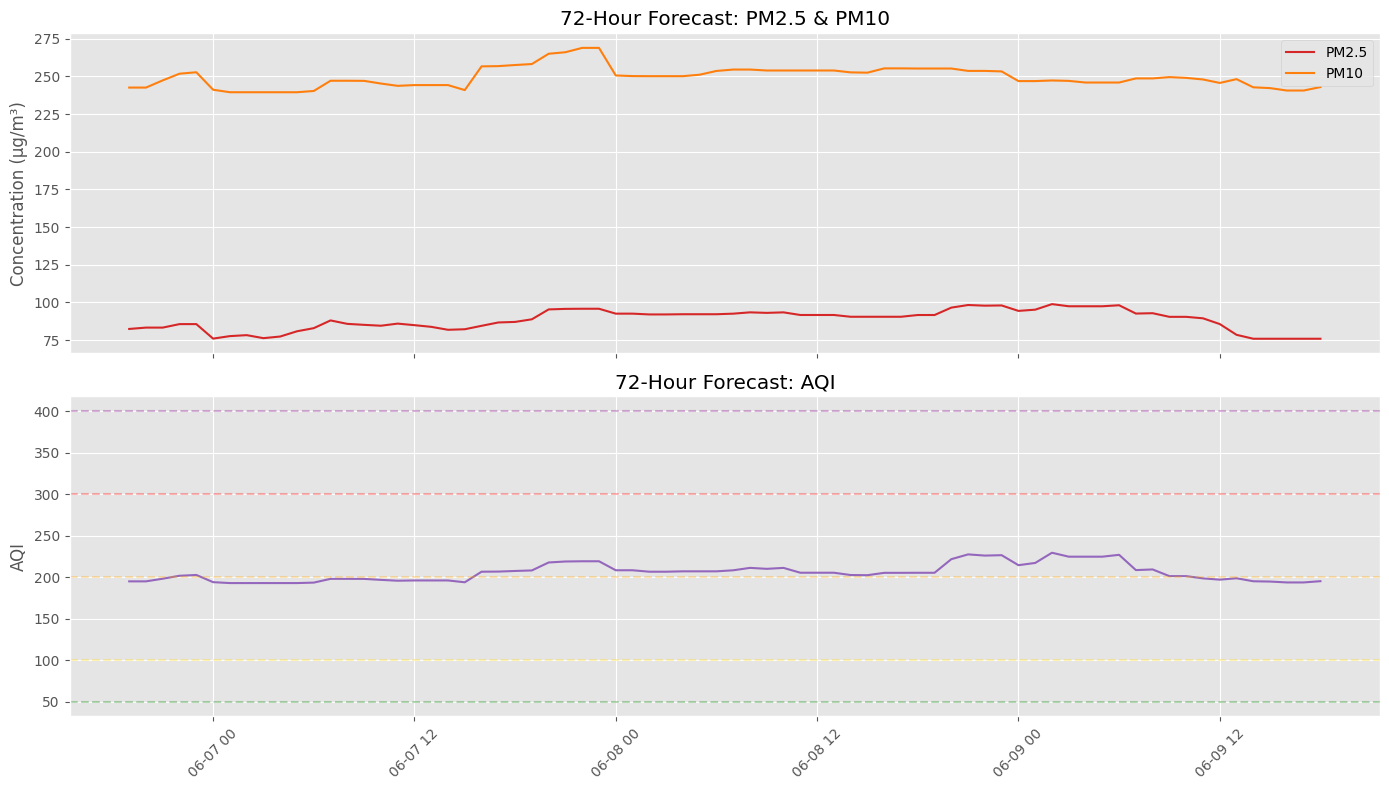

In [22]:
plt.style.use('ggplot')

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(forecast_72h["datetime"], forecast_72h["pm25"], label="PM2.5", color="tab:red")
axes[0].plot(forecast_72h["datetime"], forecast_72h["pm10"], label="PM10", color="tab:orange")
axes[0].set_ylabel("Concentration (µg/m³)")
axes[0].set_title("72-Hour Forecast: PM2.5 & PM10")
axes[0].legend()

axes[1].plot(forecast_72h["datetime"], forecast_72h["aqi"], color="tab:purple")
axes[1].set_ylabel("AQI")
axes[1].set_title("72-Hour Forecast: AQI")
for level, color in [(50, "green"), (100, "gold"), (200, "orange"), (300, "red"), (400, "purple")]:
    axes[1].axhline(level, color=color, linestyle="--", alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [26]:
# 1) 72-hour forecast — already in exactly the shape the frontend needs
forecast_export = forecast_72h.copy()
forecast_export["datetime"] = forecast_export["datetime"].dt.tz_convert("UTC").dt.strftime("%Y-%m-%dT%H:%M:%SZ")
forecast_export = forecast_export.rename(columns={"hours_ahead": "hoursFromNow", "dominant_pollutant": "pollutant"})
forecast_export["pollutant"] = forecast_export["pollutant"].map({"pm25": "PM2.5", "pm10": "PM10"})
# weather isn't forecast by the model - carry the latest known reading across all 72 rows
latest_row = get_latest_conditions(test)
forecast_export["tempC"] = round(float(latest_row["temperature_C"]), 1)
forecast_export["windSpeed"] = round(float(latest_row["wind_speed"]) * 3.6, 1)  # m/s -> km/h
forecast_export["windDir"] = float(latest_row.get("wind_dir_deg", 0))
forecast_export[["hoursFromNow", "datetime", "aqi", "pollutant", "pm25", "pm10", "tempC", "windSpeed", "windDir"]] \
    .round(1).to_csv("forecast.csv", index=False)

# 2) Past 3 days, one row per day
hist = test.dropna(subset=["pm25", "pm10"]).copy()
hist["date"] = hist["datetime"].dt.date
daily = hist.groupby("date").agg(pm25=("pm25", "mean"), pm10=("pm10", "mean"),
                                  temperature_C=("temperature_C", "mean")).reset_index().tail(3)
daily["aqi"] = daily.apply(lambda r: compute_aqi({"pm25": r["pm25"], "pm10": r["pm10"]})[0], axis=1).round().astype(int)
daily[["date", "aqi", "temperature_C"]].rename(columns={"temperature_C": "tempC"}).round(1).to_csv("history.csv", index=False)

# 3) Current reading — single-row CSV
aqi_now, dom_now = compute_aqi({"pm25": latest_row["pm25"], "pm10": latest_row["pm10"]})
pd.DataFrame([{
    "aqi": round(aqi_now), "pollutant": "PM2.5" if dom_now == "pm25" else "PM10",
    "tempC": round(float(latest_row["temperature_C"]), 1),
    "feelsC": round(float(latest_row["temperature_C"]), 1),
    "windSpeed": round(float(latest_row["wind_speed"]) * 3.6, 1),
    "windDir": float(latest_row.get("wind_dir_deg", 0)),
    "lastUpdated": latest_row["datetime"].tz_convert("UTC").strftime("%Y-%m-%dT%H:%M:%SZ"),
}]).to_csv("current.csv", index=False)

print("Wrote forecast.csv, history.csv, current.csv")

Wrote forecast.csv, history.csv, current.csv


In [27]:
import joblib

bundle = {
    "models": models,   # your trained pm25/pm10 models from cell 18
    "recent_data": df   # has datetime, pm25, pm10, and all FEATURES columns
}

joblib.dump(bundle, "aqi_model_bundle.pkl")
print("Saved aqi_model_bundle.pkl")

Saved aqi_model_bundle.pkl
